# 用户指南，第30章：案例3
[原文链接](https://www.music21.org/music21docs/usersGuide/usersGuide_30_examples3.html)

TODO

In [1]:
from music21 import *
ryans = corpus.search('ryansMammoth')
ryans

<music21.metadata.bundles.MetadataBundle {1059 entries}>

In [2]:
highland = ryans.search('Highland Regiment')
highland

<music21.metadata.bundles.MetadataBundle {1 entry}>

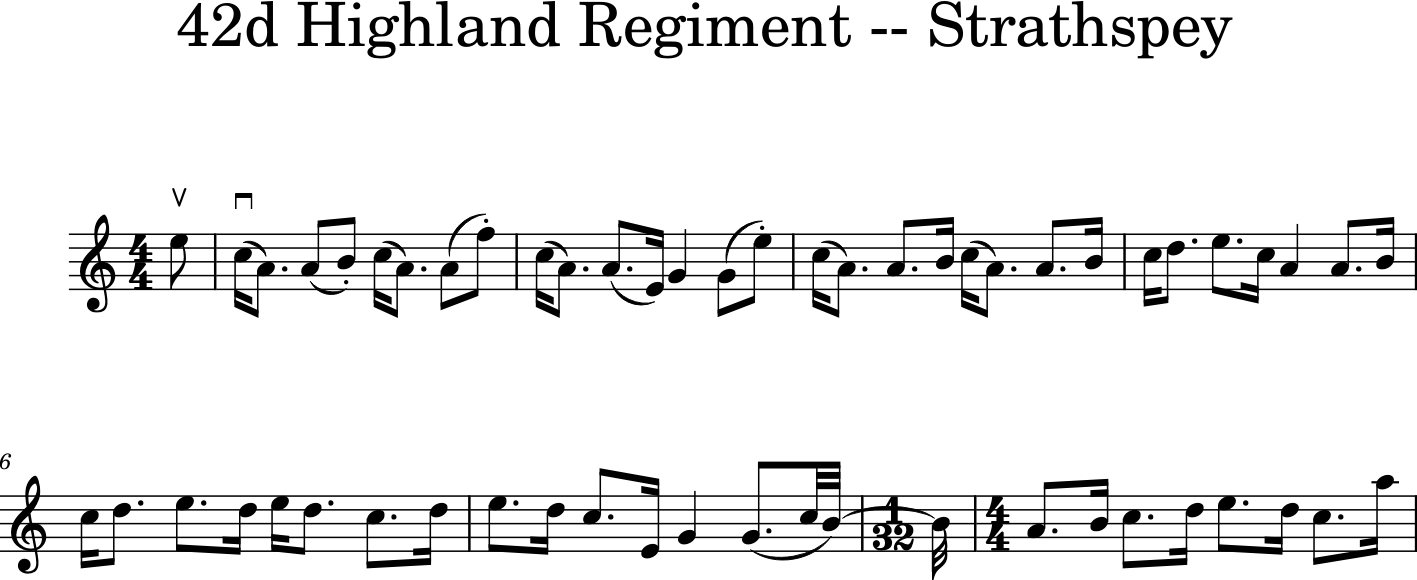

In [3]:
highlandParsed = highland[0].parse()
highlandParsed.measures(0, 8).show()

In [4]:
highlandIterator = highlandParsed.recurse()
highlandSlurs = highlandIterator.getElementsByClass('Slur')

higher = 0
lower = 0
same = 0 # could happen for slurs longer than 2 notes

for sl in highlandSlurs:
    firstNote = sl.getFirst()
    lastNote = sl.getLast()
    psDiff = lastNote.pitch.ps - firstNote.pitch.ps
    if psDiff > 0:
        higher += 1
    elif psDiff < 0:
        lower += 1
    else:
        same += 1

In [5]:
(higher, lower, same)

(19, 30, 0)

In [6]:
from statistics import mean
from collections import Counter

totalCounter = Counter()

def countOneSlur(sl, totalCounter):
    firstNote = sl.getFirst()
    lastNote = sl.getLast()
    if not hasattr(firstNote, 'pitches'):
        return
    if not hasattr(lastNote, 'pitches'):
        return

    firstNotePs = mean(p.ps for p in firstNote.pitches)
    lastNotePs = mean(p.ps for p in lastNote.pitches)
    psDiff = lastNotePs - firstNotePs
    if psDiff > 0:
        totalCounter['higher'] += 1
    elif psDiff < 0:
        totalCounter['lower'] += 1
    else:
        totalCounter['same'] += 1

In [7]:
def runOneScore(scCorpusSearchObject, totalCounter):
    scParsed = scCorpusSearchObject.parse()
    for sl in scParsed.recurse().getElementsByClass('Slur'):
        countOneSlur(sl, totalCounter)


In [8]:
runOneScore(highland[0], totalCounter)

In [9]:
totalCounter

Counter({'lower': 30, 'higher': 19})

In [10]:
totalCounter = Counter()

stop = 20
for piece in ryans:
    runOneScore(piece, totalCounter)
    stop = stop - 1
    if stop == 0:
        break


In [11]:
totalCounter

Counter({'higher': 73, 'lower': 69, 'same': 11})

In [12]:
import random

def numBiased(inCounter, trials=100, printData=False):
    chanceTrials = 0
    totalSimulations = inCounter['higher'] + inCounter['lower']
    maxValue = max([inCounter['higher'], inCounter['lower']])
    minValue = min([inCounter['higher'], inCounter['lower']])
    for trialNum in range(trials):
        randCounter = Counter()
        for flipNum in range(totalSimulations):
            if random.randint(0, 1) == 1:
                outcome = 'higher'
            else:
                outcome = 'lower'
            randCounter[outcome] += 1
        if (randCounter['higher'] < maxValue
                and randCounter['higher'] > minValue):
            chanceTrials += 1
        elif printData:
            print(randCounter)
    return chanceTrials / trials

In [13]:
numBiased(Counter({'higher': 19, 'lower': 30}), printData=True)

Counter({'higher': 31, 'lower': 18})
Counter({'lower': 31, 'higher': 18})
Counter({'higher': 31, 'lower': 18})
Counter({'lower': 34, 'higher': 15})
Counter({'higher': 33, 'lower': 16})
Counter({'lower': 30, 'higher': 19})
Counter({'higher': 30, 'lower': 19})
Counter({'higher': 30, 'lower': 19})
Counter({'higher': 30, 'lower': 19})
Counter({'higher': 30, 'lower': 19})


0.9

In [14]:
numBiased(Counter({'higher': 80, 'lower': 90, 'same': 11}))

0.48

In [15]:
totalCounter = Counter({'higher': 3321, 'lower': 3637, 'same': 425})
numBiased(totalCounter)

1.0

In [16]:
bostonMD = ryans.search('The Boston -- Reel')
bostonMD

<music21.metadata.bundles.MetadataBundle {1 entry}>

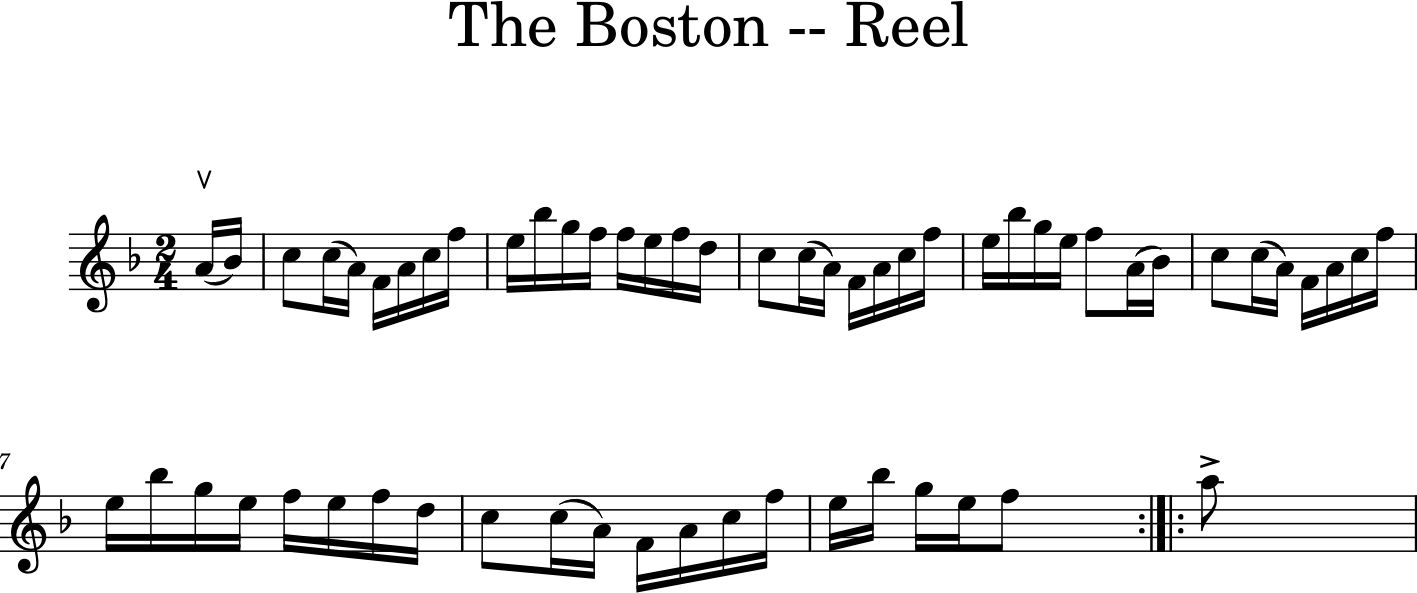

In [17]:
boston = bostonMD[0].parse()
boston.measures(0, 9).show()

In [18]:
bostonPart = boston.parts[0]
outPart = bostonPart.template(fillWithRests=False)

In [19]:
pieceKey = boston.analyze('key')
pieceKey

<music21.key.Key of F major>

In [20]:
def notesToRoman(notes):
    uniquePitches = set(n.pitch for n in notes)
    ch = chord.Chord(list(uniquePitches))
    return roman.romanNumeralFromChord(ch, pieceKey)

In [21]:
noteIterator = bostonPart.measure(1).notes
rn1 = notesToRoman(noteIterator)
rn1

<music21.roman.RomanNumeral I in F major>

In [22]:
inMeasures = list(bostonPart[stream.Measure])
outMeasures = list(outPart[stream.Measure])

for i in range(14):
    inMeasure = inMeasures[i]
    if inMeasure.duration.quarterLength != 2.0:
        continue
    outMeasure = outMeasures[i]
    
    for beatStart in (0, 1):
        beatNotes = inMeasure.getElementsByOffset(beatStart, 
                                                  beatStart + 1, 
                                                  includeEndBoundary=False
                                                 ).getElementsByClass(note.NotRest)
        beatRN = notesToRoman(beatNotes)
        beatRN.lyric = beatRN.figure
        outMeasure.insert(beatStart, beatRN)

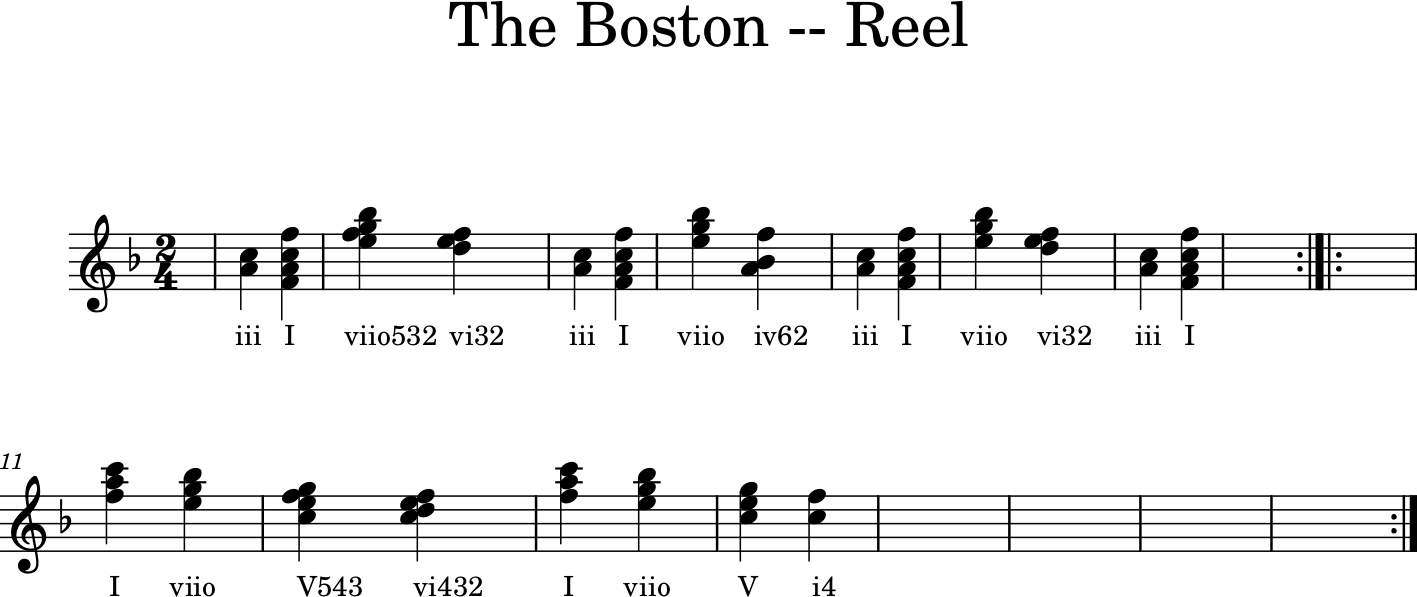

In [23]:
outPart.show()

In [24]:
def notesToRoman(notes):
    goodPitches = set()
    for n in notes:
        if (n.offset * 2) == int(n.offset * 2):
            goodPitches.add(n.pitch)
        else:
            nPrev = n.previous('Note')
            nNext = n.next('Note')
            if nPrev is None or nNext is None:
                continue
            prevInterval = interval.Interval(n, nPrev)
            nextInterval = interval.Interval(n, nNext)
            
            if (prevInterval.generic.undirected in (1, 2)
                and nextInterval.generic.undirected in (1, 2)):
                pass
            else:
                goodPitches.add(n.pitch)
    ch = chord.Chord(list(goodPitches))
    return roman.romanNumeralFromChord(ch, pieceKey)

In [25]:
iii = roman.RomanNumeral('iii')
iii.functionalityScore

15

In [26]:
outPart = bostonPart.template(fillWithRests=False)

inMeasures = list(bostonPart[stream.Measure])
outMeasures = list(outPart[stream.Measure])

for i in range(14):
    inMeasure = inMeasures[i]
    if inMeasure.duration.quarterLength != 2.0:
        continue
    outMeasure = outMeasures[i]
    
    for beatStart in (0, 1):
        beatNotes = inMeasure.getElementsByOffset(beatStart, 
                                                  beatStart + 1, 
                                                  includeEndBoundary=False
                                                 ).getElementsByClass(note.NotRest)
        beatRN = notesToRoman(beatNotes)
        if beatRN.functionalityScore > 15:
            beatRN.lyric = beatRN.figure
        outMeasure.insert(beatStart, beatRN)

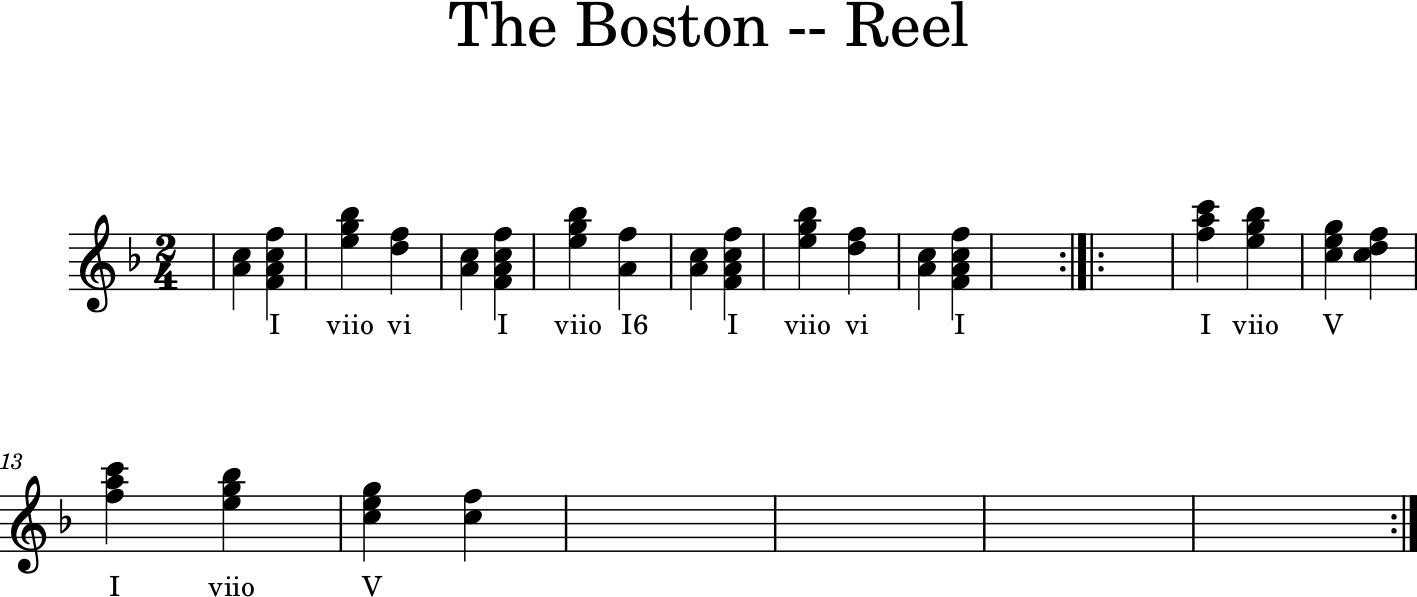

In [27]:
outPart.show()

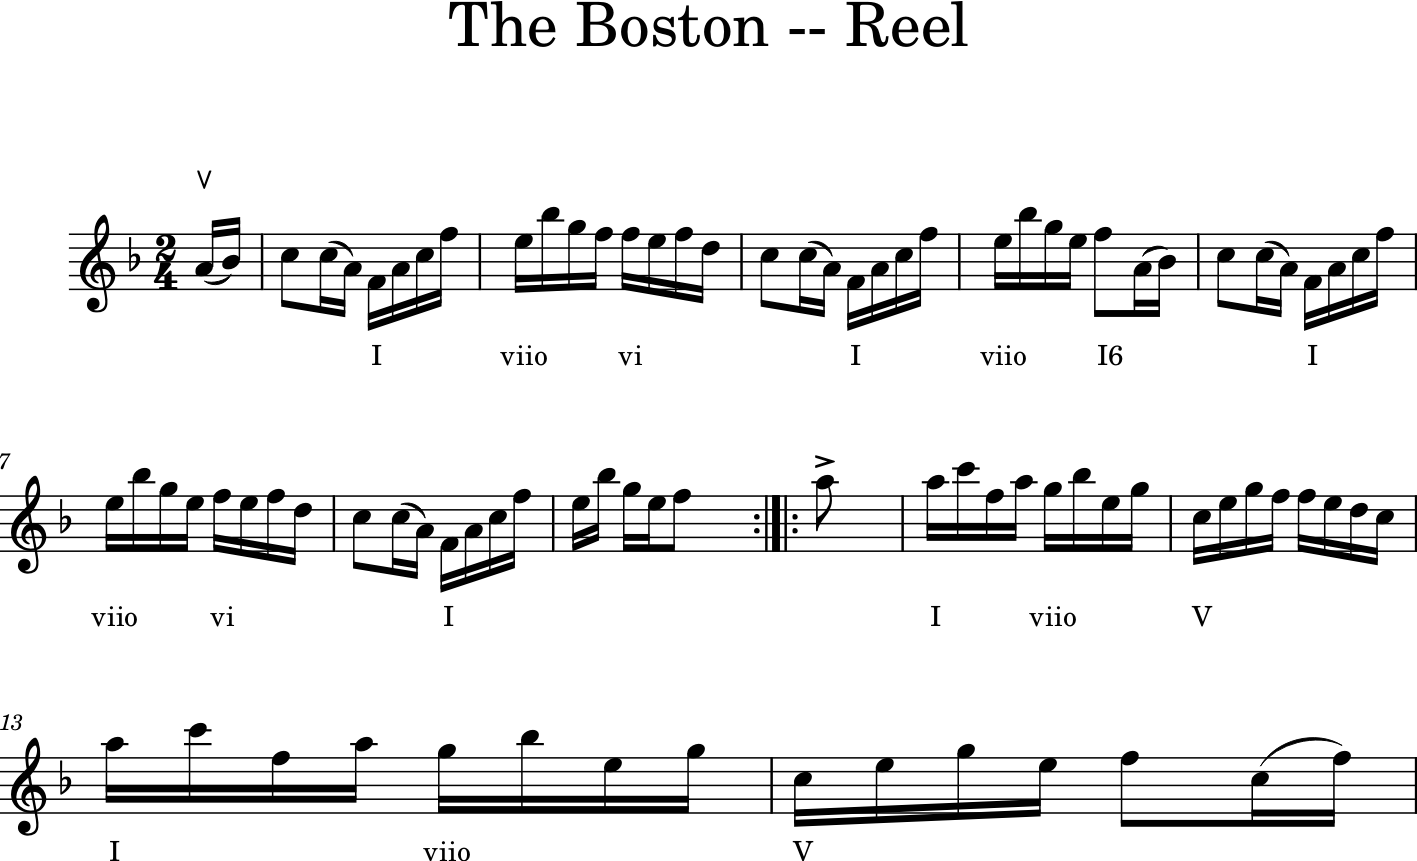

In [28]:
inMeasures = list(bostonPart[stream.Measure])

for i in range(14):
    inMeasure = inMeasures[i]
    if inMeasure.duration.quarterLength != 2.0:
        continue
    
    for beatStart in (0, 1):
        beatNotes = inMeasure.getElementsByOffset(beatStart, 
                                                  beatStart + 1, 
                                                  includeEndBoundary=False
                                                 ).getElementsByClass(note.NotRest)
        beatRN = notesToRoman(beatNotes)
        if beatRN.functionalityScore > 15:
            beatNotes[0].lyric = beatRN.figure

bostonPart.measures(0, 13).show()

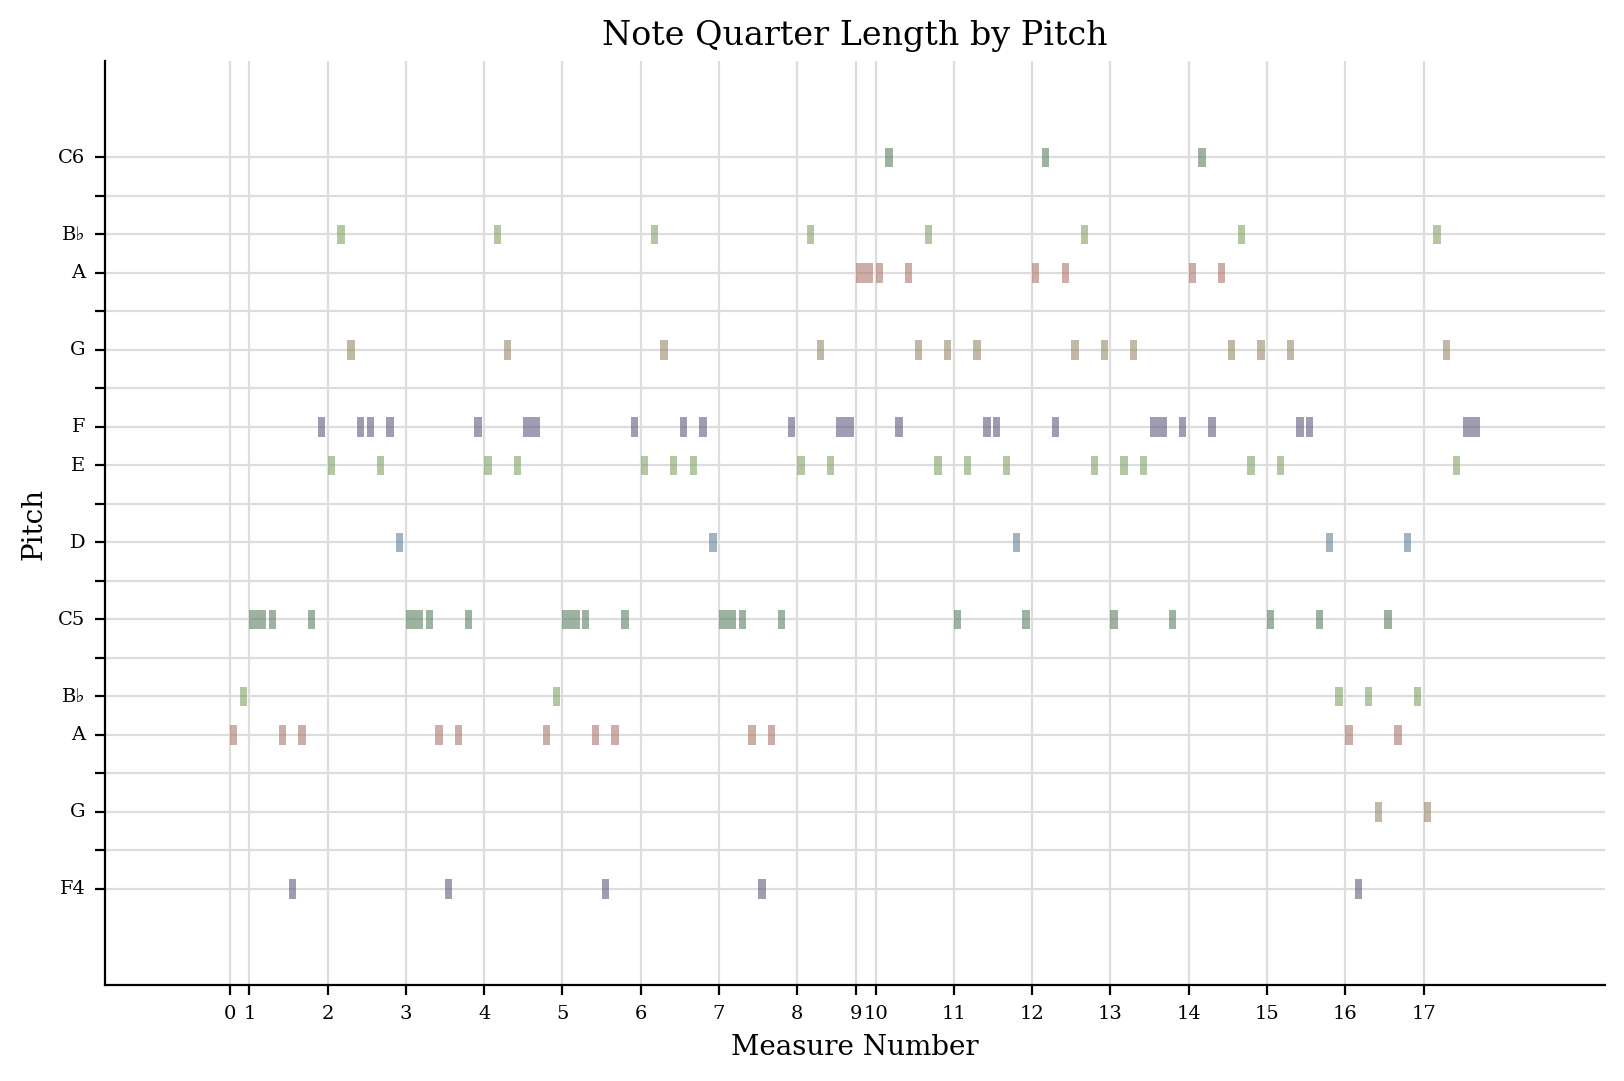

In [29]:
bostonPart.plot('pianoroll')

In [30]:
bostonPart.measures(10, 15).analyze('key')

<music21.key.Key of F major>

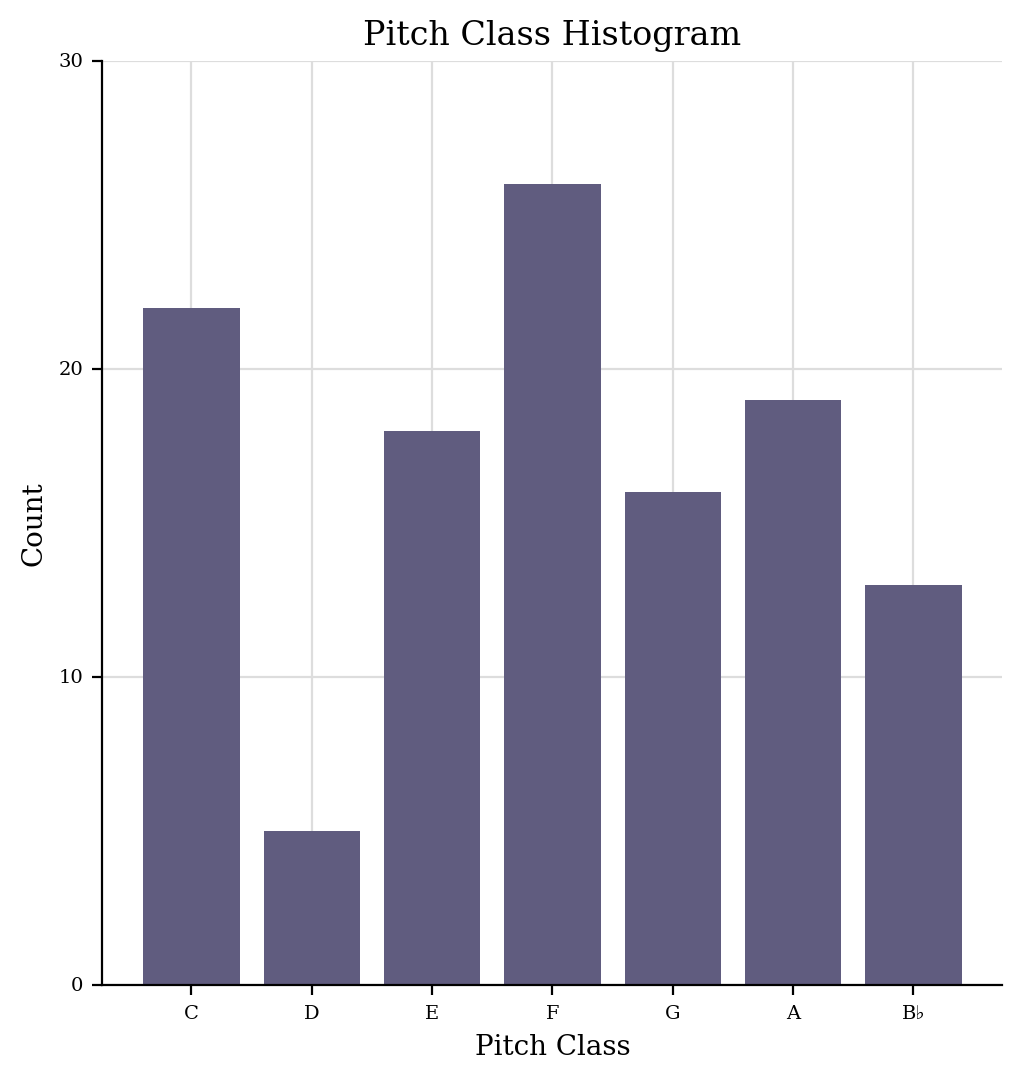

In [31]:
bostonPart.plot('histogram', 'pitchClass')

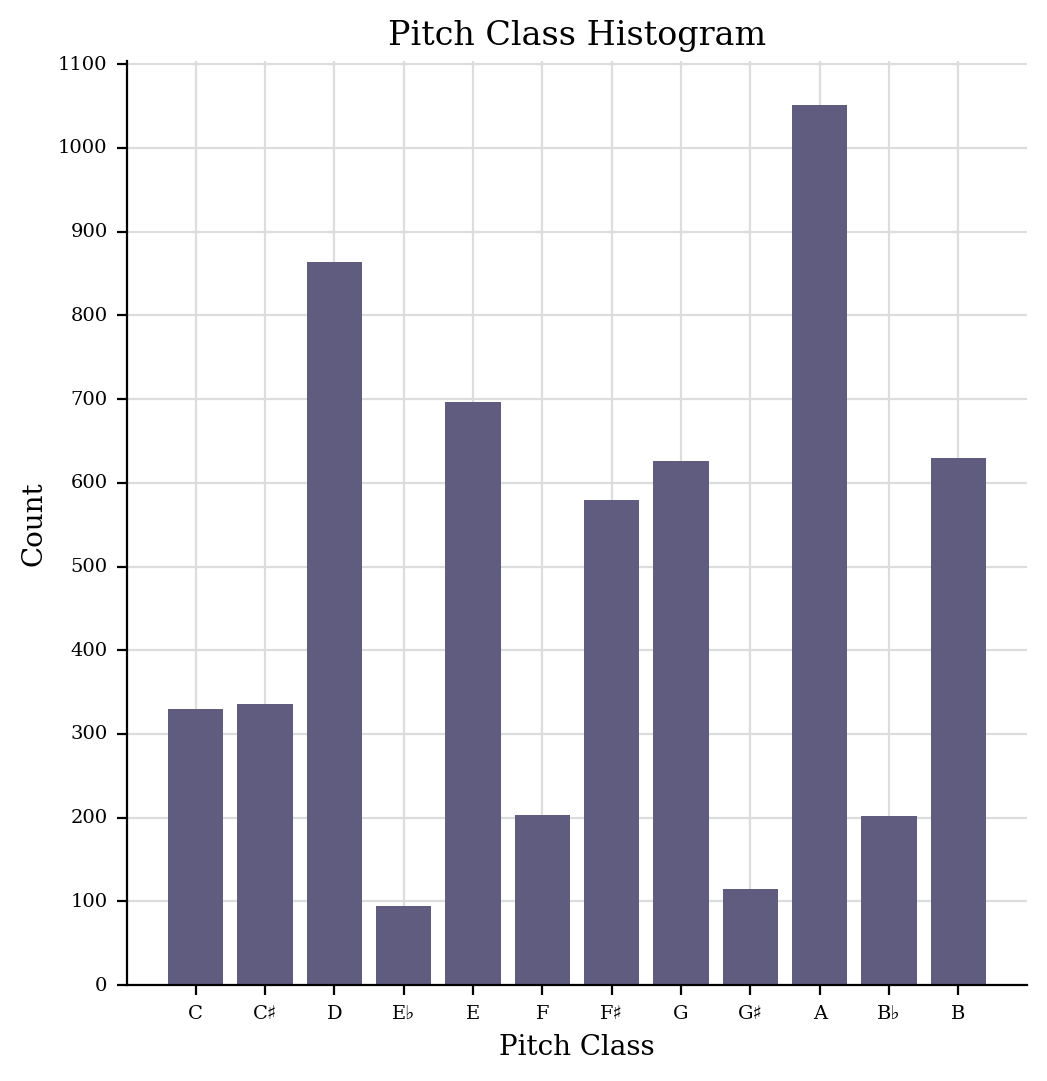

In [32]:
manyScores = stream.Opus()

for i in range(50):
    sc = ryans[i].parse()
    manyScores.insert(0, sc)

manyScores.plot('histogram', 'pitchClass')